# Mandarin Tone Discrimination — Pre-trained Whisper Models

Evaluate OpenAI Whisper encoder representations (whisper-tiny, whisper-large-v3)
on the zero-shot Mandarin tone discrimination triplet task.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import whisper
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from tqdm.auto import tqdm

import sys
sys.path.append('../')
sys.path.append('../lightning_scripts')

from lightning_scripts.tone_perfect_triplet_dataset import TonePerfectDataset

import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    normalize_model_name,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    model_label,
    plot_grouped_bars,
)

torch.set_float32_matmul_precision("medium")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

%matplotlib inline

Using device: cuda


## Whisper Encoder Wrapper

Wraps a pre-trained Whisper encoder so it accepts raw 16 kHz waveforms
shaped `(B, 1, T)` and returns time-averaged embeddings `(B, D)`,
compatible with the triplet evaluation utilities.

In [2]:
class WhisperEncoderWrapper(nn.Module):
    """Wrap a pretrained Whisper encoder for embedding extraction.

    Accepts raw waveform (B, 1, T) at 16 kHz and returns (B, D).
    Features are extracted from a specified encoder block and
    time-averaged to produce a fixed-size representation.
    """

    def __init__(self, whisper_model_name: str, encoder_layer: int = -1):
        super().__init__()
        model = whisper.load_model(whisper_model_name)
        self.encoder = model.encoder
        self.n_mels = model.dims.n_mels

        for p in self.encoder.parameters():
            p.requires_grad = False
        self.encoder.eval()

        num_blocks = len(self.encoder.blocks)
        self.use_ln_post = (encoder_layer == -1)

        if not self.use_ln_post:
            if encoder_layer < 0:
                encoder_layer = num_blocks + encoder_layer
            self.encoder_layer = encoder_layer
            self._layer_output = None
            self.encoder.blocks[self.encoder_layer].register_forward_hook(self._hook)

    def _hook(self, _module, _input, output):
        out = output[0] if isinstance(output, tuple) else output
        self._layer_output = out

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 3:
            x = x.squeeze(1)  # (B, 1, T) -> (B, T)
        mel = whisper.log_mel_spectrogram(x, n_mels=self.n_mels).to(x.device)
        mel = whisper.pad_or_trim(mel, 3000)
        with torch.no_grad():
            encoder_out = self.encoder(mel)
        if self.use_ln_post:
            feats = encoder_out  # (B, T_enc, D) — after all blocks + ln_post
        else:
            feats = self._layer_output  # (B, T_enc, D)
            self._layer_output = None
        return feats.flatten(start_dim=1)  # (B, T_enc * D)

## Load Pre-trained Whisper Models

In [3]:
whisper_specs = {
    "whisper_tiny": {"name": "tiny", "layer": -1},
    "whisper_large_v3": {"name": "large-v3", "layer": -1},
}

models = {}
model_name_map = {}

for key, spec in whisper_specs.items():
    print(f"Loading {spec['name']}...")
    wrapper = WhisperEncoderWrapper(spec["name"], encoder_layer=spec["layer"])
    wrapper.to(DEVICE)
    models[key] = wrapper
    model_name_map[key] = f"Whisper {spec['name']}"

print(f"Loaded {len(models)} Whisper models")

Loading tiny...


100%|█████████████████████████████████████| 72.1M/72.1M [00:00<00:00, 79.3MiB/s]


Loading large-v3...


100%|█████████████████████████████████████| 2.88G/2.88G [00:50<00:00, 60.6MiB/s]


Loaded 2 Whisper models


## Dataset Setup

In [4]:
WHISPER_SR = 16_000
n_examples = 2000

tone_perfect_dir = Path("~/ceph/datasets/tone_perfect").expanduser()
tp_dataset = TonePerfectDataset(
    tone_perfect_dir,
    resample_sr=WHISPER_SR,
    pair_mode=True,
    include_negative=True,
    allow_tone1=True,
    n_examples=n_examples,
    random_seed=0,
)

print(f"Dataset ready: {len(tp_dataset)} triplets at target_sr={tp_dataset.resample_sr}")

def mandarin_triplet_collate(batch):
    clips, sr, triplet = batch[0]
    return clips, sr, triplet

tp_loader = torch.utils.data.DataLoader(
    tp_dataset, batch_size=1, shuffle=False, collate_fn=mandarin_triplet_collate
)

Generating 500 triplets per tone (total: 2000)...
  Tone 1: generated 500/500 triplets
  Tone 2: generated 500/500 triplets
  Tone 3: generated 500/500 triplets
  Tone 4: generated 500/500 triplets
Total triplets generated: 2000
Dataset ready: 2000 triplets at target_sr=16000


## Run Triplet Evaluation

In [8]:
def batched_pearson_corrcoef(x, y, dim=-1):
    mean_x = torch.mean(x, dim=dim, keepdim=True)
    mean_y = torch.mean(y, dim=dim, keepdim=True)
    xm = x - mean_x
    ym = y - mean_y
    r_num = torch.sum(xm * ym, dim=dim)
    r_den = torch.sqrt(torch.sum(xm ** 2, dim=dim) * torch.sum(ym ** 2, dim=dim))
    return r_num / r_den


def whisper_distance_metrics(model, clips, device):
    """Compute triplet distance metrics for a WhisperEncoderWrapper."""
    waves = {k: v.to(device) for k, v in clips.items()}

    z_a = model(waves["anchor"].unsqueeze(0).unsqueeze(0))
    z_p = model(waves["positive"].unsqueeze(0).unsqueeze(0))
    z_n = model(waves["negative"].unsqueeze(0).unsqueeze(0))

    pos_l2 = torch.norm(z_a - z_p, p=2).item()
    neg_l2 = torch.norm(z_a - z_n, p=2).item()
    pos_cos = F.cosine_similarity(z_a, z_p).item()
    neg_cos = F.cosine_similarity(z_a, z_n).item()
    pos_r = batched_pearson_corrcoef(z_a, z_p, dim=-1).item()
    neg_r = batched_pearson_corrcoef(z_a, z_n, dim=-1).item()

    return {
        "pos_l2": pos_l2,
        "neg_l2": neg_l2,
        "pos_l2_sq": pos_l2 ** 2,
        "neg_l2_sq": neg_l2 ** 2,
        "l2_judgement": int(pos_l2 < neg_l2),
        "sqr_l2_judgement": int(pos_l2 ** 2 < neg_l2 ** 2),
        "judgement_pos_lt_neg": int(pos_l2 < neg_l2),
        "pos_cos": pos_cos,
        "neg_cos": neg_cos,
        "cos_judgement": int(pos_cos > neg_cos),
        "pos_r": pos_r,
        "neg_r": neg_r,
        "r_judgement": int(pos_r > neg_r),
    }


records = []
for batch_idx, (clips, sr, triplet) in tqdm(
    enumerate(tp_loader), total=len(tp_loader), desc="Evaluating triplets"
):
    if clips["anchor"] is None or clips["positive"] is None or clips["negative"] is None:
        continue

    for internal_name, model in models.items():
        metrics = whisper_distance_metrics(model, clips, device=DEVICE)
        metrics.update({
            "example_idx": batch_idx,
            "model": internal_name,
            "model_name": model_name_map[internal_name],
            "speaker": triplet["anchor"].get("speaker", None),
            "tone": triplet["anchor"].get("tone", None),
            "syllable_a": triplet["anchor"].get("syllable", None),
            "syllable_b": triplet["positive"].get("syllable", None),
            "neg_tone": triplet["negative"].get("tone", None),
        })
        records.append(metrics)

whisper_tone_df = pd.DataFrame(records)
print(
    f"Evaluated {whisper_tone_df.example_idx.nunique()} triplets; "
    f"{len(whisper_tone_df)} model-evals"
)
whisper_tone_df.head()

Evaluating triplets:   0%|          | 0/2000 [00:00<?, ?it/s]

Evaluated 1999 triplets; 3998 model-evals


,pos_l2,neg_l2,pos_l2_sq,neg_l2_sq,l2_judgement,sqr_l2_judgement,judgement_pos_lt_neg,pos_cos,neg_cos,cos_judgement,...,neg_r,r_judgement,example_idx,model,model_name,speaker,tone,syllable_a,syllable_b,neg_tone
0,1.268762,1.845255,1.609756,3.404965,1,1,1,0.999181,0.998261,1,...,0.998174,1,0,whisper_tiny,Whisper tiny,male_voice_1,3,chuan3,kuang3,4
1,1.270420,2.192069,1.613968,4.805168,1,1,1,0.999297,0.997177,1,...,0.995562,1,0,whisper_large_v3,Whisper large-v3,male_voice_1,3,chuan3,kuang3,4
2,2.254073,3.147655,5.080847,9.907734,1,1,1,0.997715,0.994887,1,...,0.994639,1,1,whisper_tiny,Whisper tiny,female_voice_2,4,kuai4,ru4,2
3,2.123157,2.539671,4.507795,6.449931,1,1,1,0.998348,0.997948,1,...,0.997751,1,1,whisper_large_v3,Whisper large-v3,female_voice_2,4,kuai4,ru4,2
4,1.705132,2.736092,2.907474,7.486197,1,1,1,0.998628,0.996674,1,...,0.996512,1,2,whisper_tiny,Whisper tiny,female_voice_1,2,nu2,fei2,4


## Save Results

In [9]:
out_dir = Path("../results_dfs")
out_dir.mkdir(exist_ok=True, parents=True)
whisper_tone_df.to_csv(out_dir / "zero_shot_mandarin_tone_whisper_pretrained.csv", index=False)
print(f"Saved to {out_dir / 'zero_shot_mandarin_tone_whisper_pretrained.csv'}")

Saved to ../results_dfs/zero_shot_mandarin_tone_whisper_pretrained.csv


## Plot Results

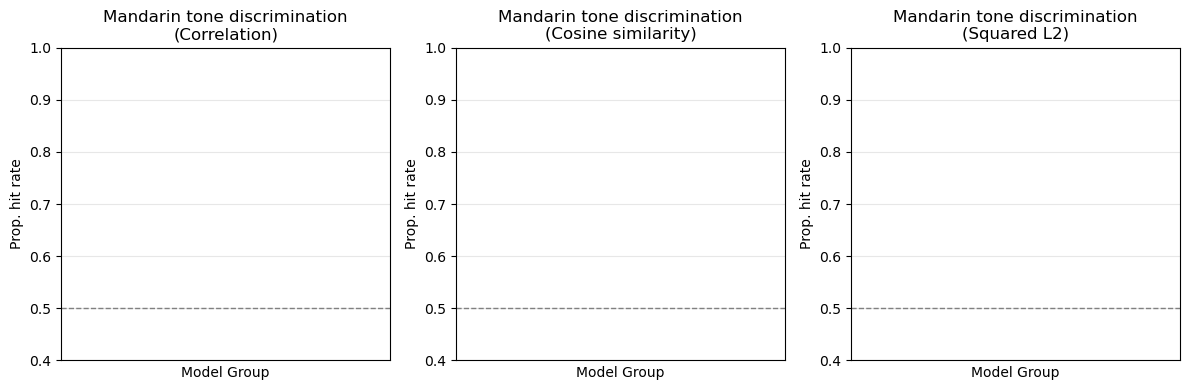

In [10]:
import seaborn as sns

whisper_model_names = whisper_tone_df['model_name'].unique().tolist()
whisper_colors = sns.color_palette('Oranges', n_colors=max(len(whisper_model_names), 3))
palette = {name: whisper_colors[i] for i, name in enumerate(whisper_model_names)}

metrics_to_plot = [
    ("r_judgement", "Correlation"),
    ("cos_judgement", "Cosine similarity"),
    ("sqr_l2_judgement", "Squared L2"),
]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(4 * len(metrics_to_plot), 4))

for ax, (metric, metric_label) in zip(axes, metrics_to_plot):
    means = whisper_tone_df.groupby('model_name')[metric].mean()
    sems = whisper_tone_df.groupby('model_name')[metric].sem()

    means = means.reindex(whisper_model_names)
    sems = sems.reindex(whisper_model_names)

    bars = ax.bar(
        range(len(whisper_model_names)),
        means.values,
        yerr=sems.values,
        color=[palette[m] for m in whisper_model_names],
        edgecolor='black',
        linewidth=0.6,
        capsize=4,
    )
    ax.set_xticks(range(len(whisper_model_names)))
    ax.set_xticklabels(whisper_model_names, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel('Prop. hit rate')
    ax.set_title(f'Mandarin tone discrimination\n({metric_label})')
    ax.set_ylim(0.4, 1.0)
    ax.axhline(0.5, color='grey', linestyle='--', linewidth=1)
    ax.grid(axis='y', alpha=0.3, zorder=-1)

plt.tight_layout()
plt.show()

## Summary Table

In [11]:
summary = (
    whisper_tone_df
    .groupby("model_name")
    [["r_judgement", "cos_judgement", "sqr_l2_judgement"]]
    .agg(["mean", "sem"])
)
summary.columns = [f"{col}_{stat}" for col, stat in summary.columns]
summary

,r_judgement_mean,r_judgement_sem,cos_judgement_mean,cos_judgement_sem,sqr_l2_judgement_mean,sqr_l2_judgement_sem
model_name,,,,,,
Whisper large-v3,0.611806,0.010903,0.622311,0.010846,0.631816,0.010790
Whisper tiny,0.738369,0.009833,0.736368,0.009857,0.720360,0.010041
